## Skin Cancer Detection

##  Install & Import Libraries

In [1]:


import os, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print(f'✅ TensorFlow version : {tf.__version__}')
print(f'✅ NumPy version      : {np.__version__}')
print(f'✅ GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ TensorFlow version : 2.18.1
✅ NumPy version      : 1.26.4
✅ GPU available      : False


In [2]:

IMAGE_DIR = r"C:\Users\VAIBHAV PRABHU\Downloads\archive\images"  

# Path to your GroundTruth CSV file
CSV_PATH  = r"C:\Users\VAIBHAV PRABHU\Downloads\archive\GroundTruth.csv"  

# Where to save the trained model
MODEL_SAVE_PATH = r'C:\Users\VAIBHAV PRABHU\skin_cancer\skin_cancer_model.keras'

# ── Config ────────────────────────────────────────────────────────────
IMG_SIZE    = 128   # Use 128 for faster training; 224 for best accuracy
BATCH_SIZE  = 32
EPOCHS      = 50
RANDOM_SEED = 42

CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
NUM_CLASSES = len(CLASS_NAMES)

CLASS_FULL_NAMES = {
    'MEL'  : 'Melanoma',
    'NV'   : 'Melanocytic Nevi',
    'BCC'  : 'Basal Cell Carcinoma',
    'AKIEC': 'Actinic Keratosis',
    'BKL'  : 'Benign Keratosis',
    'DF'   : 'Dermatofibroma',
    'VASC' : 'Vascular Lesions'
}

print('✅ Paths configured')
print(f'   Image dir  : {IMAGE_DIR}')
print(f'   CSV file   : {CSV_PATH}')
print(f'   Image size : {IMG_SIZE}x{IMG_SIZE}')
print(f'   Batch size : {BATCH_SIZE}')
print(f'   Epochs     : {EPOCHS}')

✅ Paths configured
   Image dir  : C:\Users\VAIBHAV PRABHU\Downloads\archive\images
   CSV file   : C:\Users\VAIBHAV PRABHU\Downloads\archive\GroundTruth.csv
   Image size : 128x128
   Batch size : 32
   Epochs     : 50


##  Load & Analyze the CSV

In [3]:
# ── Load CSV ──────────────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\VAIBHAV PRABHU\Downloads\archive\GroundTruth.csv")
print(f'Total images in CSV : {len(df)}')
print(f'Columns             : {list(df.columns)}')
print('\nFirst 5 rows:')
display(df.head())

# ── Convert one-hot → single integer label ───────────────────────────
df['label'] = df[CLASS_NAMES].values.argmax(axis=1)
df['class_name'] = df['label'].map(dict(enumerate(CLASS_NAMES)))

# ── Build full image path ─────────────────────────────────────────────
df['filepath'] = df['image'].apply(
    lambda x: os.path.join(IMAGE_DIR, x + '.jpg')
)

# ── Verify files exist ────────────────────────────────────────────────
df['exists'] = df['filepath'].apply(os.path.exists)
found    = df['exists'].sum()
missing  = (~df['exists']).sum()
print(f'\n✅ Images found   : {found}')
print(f'❌ Images missing : {missing}')

if missing > 0:
    print('\n⚠️  Sample missing paths:')
    print(df[~df['exists']]['filepath'].head(3).tolist())
    print('   → Fix IMAGE_DIR path above!')

# Keep only rows where image file exists
df = df[df['exists']].reset_index(drop=True)
print(f'\nUsable dataset size: {len(df)}')

Total images in CSV : 10015
Columns             : ['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

First 5 rows:


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0



✅ Images found   : 10015
❌ Images missing : 0

Usable dataset size: 10015


##  Visualize Class Distribution

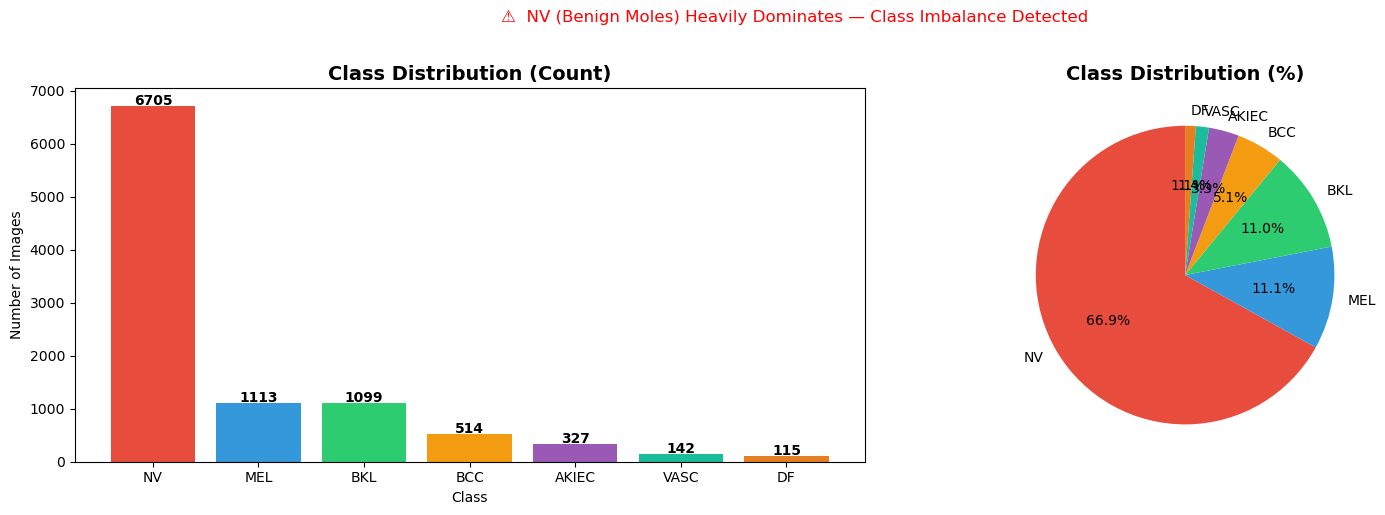


Class breakdown:
  NV     (Melanocytic Nevi              ):  6705 images (66.9%)
  MEL    (Melanoma                      ):  1113 images (11.1%)
  BKL    (Benign Keratosis              ):  1099 images (11.0%)
  BCC    (Basal Cell Carcinoma          ):   514 images (5.1%)
  AKIEC  (Actinic Keratosis             ):   327 images (3.3%)
  VASC   (Vascular Lesions              ):   142 images (1.4%)
  DF     (Dermatofibroma                ):   115 images (1.1%)


In [4]:
# ── Class distribution ────────────────────────────────────────────────
class_counts = df['class_name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']
axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt + 20, str(cnt), ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('⚠️  NV (Benign Moles) Heavily Dominates — Class Imbalance Detected',
             fontsize=12, color='red', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nClass breakdown:')
for cls, cnt in class_counts.items():
    full = CLASS_FULL_NAMES[cls]
    pct  = cnt / len(df) * 100
    print(f'  {cls:6s} ({full:30s}): {cnt:5d} images ({pct:.1f}%)')

##  Visualize Sample Images

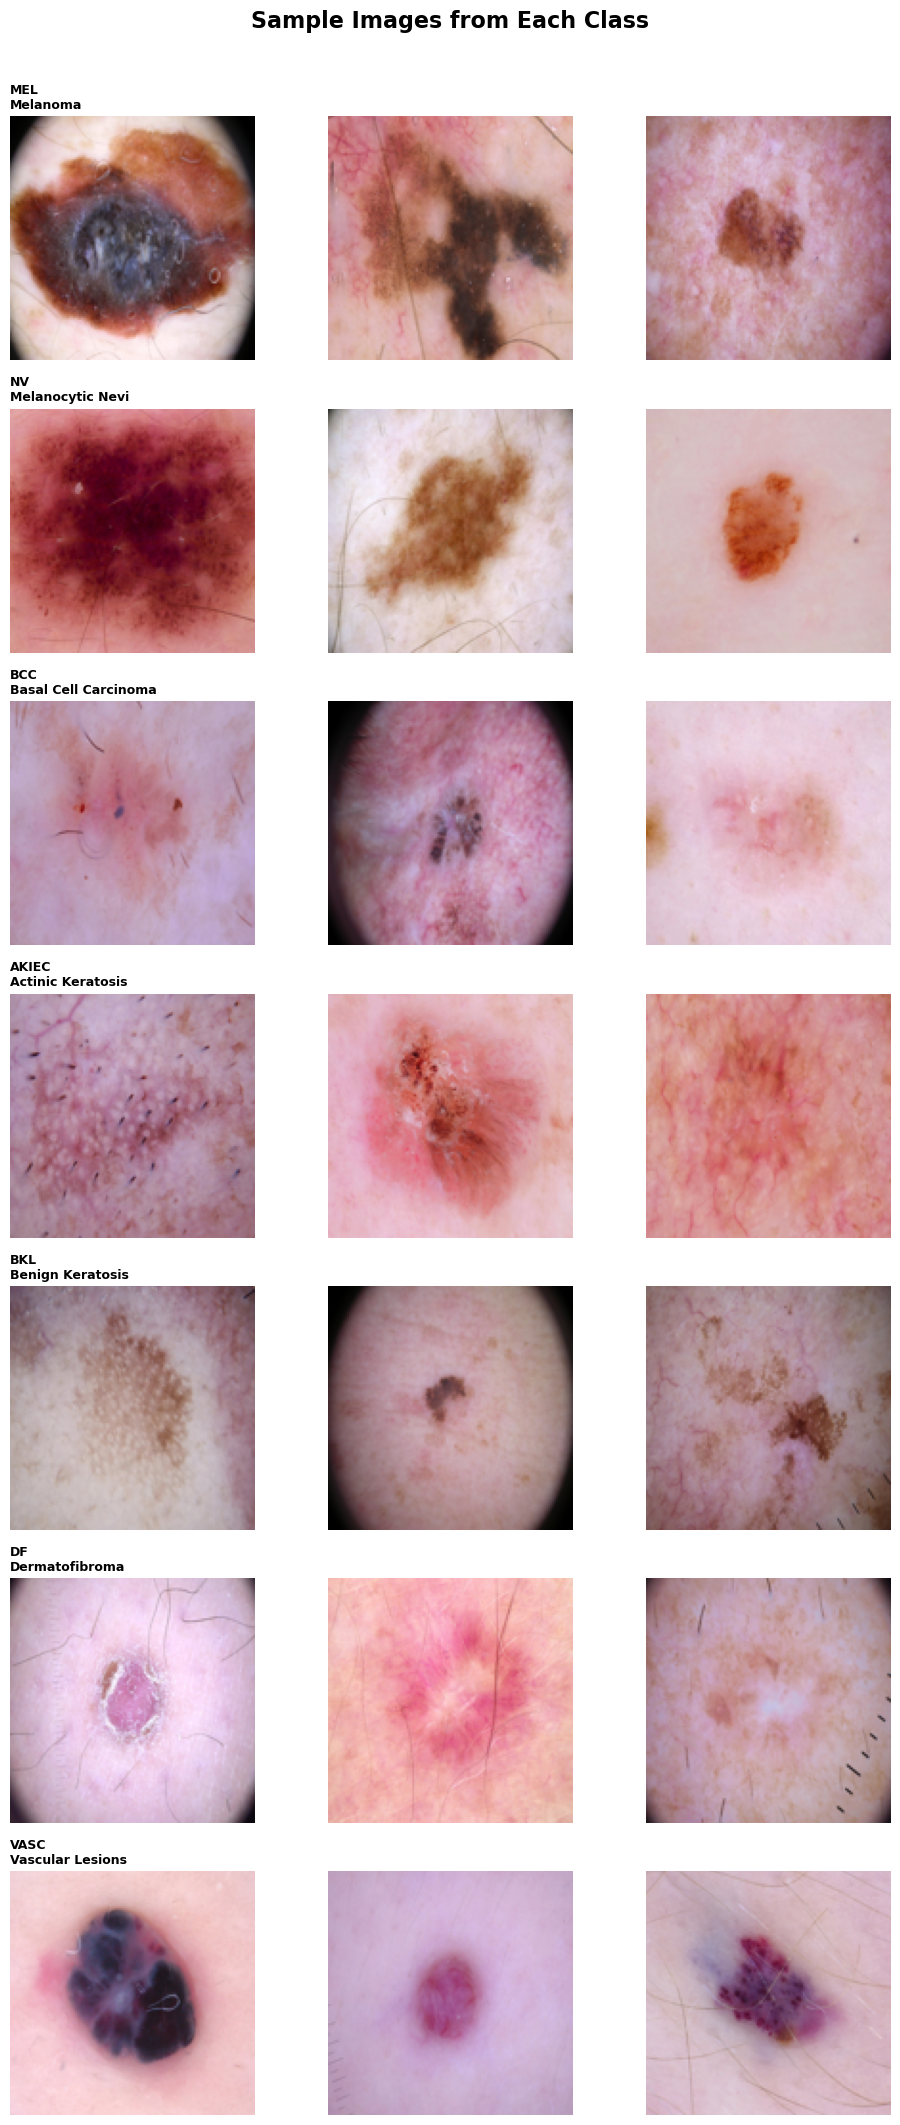

In [5]:
# ── Show 3 sample images from each class ─────────────────────────────
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(10, NUM_CLASSES * 3))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.01)

for row_idx, cls in enumerate(CLASS_NAMES):
    samples = df[df['class_name'] == cls].sample(
        min(3, len(df[df['class_name'] == cls])), random_state=RANDOM_SEED
    )
    for col_idx, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row['filepath']).resize((128, 128))
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_title(
                f"{cls}\n{CLASS_FULL_NAMES[cls]}",
                fontsize=9, fontweight='bold', loc='left'
            )

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

##  Train / Validation / Test Split

In [6]:
# ── Stratified split: 70% train, 15% val, 15% test ───────────────────
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=RANDOM_SEED
)

print(f'Train size      : {len(train_df):5d} images')
print(f'Validation size : {len(val_df):5d} images')
print(f'Test size       : {len(test_df):5d} images')

# ── Compute class weights to handle imbalance ─────────────────────────
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label'].values
)
class_weight_dict = dict(enumerate(class_weights_array))

print('\nClass weights (higher = rarer class gets more attention):')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  Class {i} {cls:6s}: weight = {class_weight_dict[i]:.3f}')

Train size      :  7010 images
Validation size :  1502 images
Test size       :  1503 images

Class weights (higher = rarer class gets more attention):
  Class 0 MEL   : weight = 1.286
  Class 1 NV    : weight = 0.213
  Class 2 BCC   : weight = 2.782
  Class 3 AKIEC : weight = 4.373
  Class 4 BKL   : weight = 1.302
  Class 5 DF    : weight = 12.363
  Class 6 VASC  : weight = 10.115


##  Build tf.data Pipeline with Augmentation

In [7]:
# ── Image loading & normalization ─────────────────────────────────────
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

# ── Augmentation (only for training) ─────────────────────────────────
def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
    img = tf.image.random_hue(img, max_delta=0.05)
    # Random 90-degree rotation via transpose
    img = tf.image.rot90(img, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
    img = tf.clip_by_value(img, 0.0, 1.0)  # Keep values in [0,1]
    return img, label

# ── Dataset builder ────────────────────────────────────────────────────
def make_dataset(dataframe, training=True):
    paths  = dataframe['filepath'].values
    labels = dataframe['label'].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(buffer_size=1000, seed=RANDOM_SEED)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df,   training=False)
test_ds  = make_dataset(test_df,  training=False)

# ── Quick sanity check ─────────────────────────────────────────────────
for images, labels in train_ds.take(1):
    print(f'✅ Batch shape  : {images.shape}')   # (32, 128, 128, 3)
    print(f'✅ Labels shape : {labels.shape}')   # (32,)
    print(f'✅ Pixel range  : [{images.numpy().min():.2f}, {images.numpy().max():.2f}]')

✅ Batch shape  : (32, 128, 128, 3)
✅ Labels shape : (32,)
✅ Pixel range  : [0.00, 1.00]


##  Build the Custom CNN Model

In [8]:
def build_skin_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """
    Custom CNN with 5 convolutional blocks + classifier head.
    Architecture inspired by VGG-style blocks with BatchNorm & Dropout.
    """
    inputs = tf.keras.Input(shape=input_shape, name='input_image')

    # ── Block 1: 32 filters ───────────────────────────────────────────
    x = layers.Conv2D(32, 3, padding='same', activation='relu', name='conv1_1')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu', name='conv1_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, name='pool1')(x)
    x = layers.Dropout(0.20)(x)

    # ── Block 2: 64 filters ───────────────────────────────────────────
    x = layers.Conv2D(64, 3, padding='same', activation='relu', name='conv2_1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu', name='conv2_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, name='pool2')(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 3: 128 filters ──────────────────────────────────────────
    x = layers.Conv2D(128, 3, padding='same', activation='relu', name='conv3_1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu', name='conv3_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, name='pool3')(x)
    x = layers.Dropout(0.30)(x)

    # ── Block 4: 256 filters ──────────────────────────────────────────
    x = layers.Conv2D(256, 3, padding='same', activation='relu', name='conv4_1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu', name='conv4_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, name='pool4')(x)
    x = layers.Dropout(0.35)(x)

    # ── Block 5: 512 filters ──────────────────────────────────────────
    x = layers.Conv2D(512, 3, padding='same', activation='relu', name='conv5_1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, name='pool5')(x)
    x = layers.Dropout(0.40)(x)

    # ── Classifier Head ───────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name='gap')(x)   # Better than Flatten
    x = layers.Dense(512, activation='relu', name='fc1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.50)(x)
    x = layers.Dense(256, activation='relu', name='fc2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = tf.keras.Model(inputs, outputs, name='SkinCancerCNN')
    return model


model = build_skin_cnn()
model.summary()

total_params = model.count_params()
print(f'\n✅ Total parameters: {total_params:,}')

Model: "SkinCancerCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_1 (Conv2D)                     │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_2 (Conv2D)                     │ (None, 128, 128, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2_1 (Conv2D)                     │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2_2 (Conv2D)                     │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3_1 (Conv2D)                     │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3_2 (Conv2D)                     │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool3 (MaxPooling2D)                 │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 2,757,159 (10.52 MB)

 Trainable params: 2,752,679 (10.50 MB)

 Non-trainable params: 4,480 (17.50 KB)


✅ Total parameters: 2,757,159


##  Compile the Model

In [9]:
# ── Compile ───────────────────────────────────────────────────────────
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_accuracy')
    ]
)

print('✅ Model compiled successfully')
print('   Optimizer  : Adam (lr=0.001)')
print('   Loss       : Sparse Categorical Cross-Entropy')
print('   Metrics    : accuracy, top-2 accuracy')

✅ Model compiled successfully
   Optimizer  : Adam (lr=0.001)
   Loss       : Sparse Categorical Cross-Entropy
   Metrics    : accuracy, top-2 accuracy


##  Train the Model

In [11]:
# ── Training Configuration ─────────────────────────────────────────────
EPOCHS = 15   # Reduced from 50 to speed up training

# ── Callbacks ─────────────────────────────────────────────────────────
cb_list = [
    # Save the best model automatically
    callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # Stop early if no improvement for 5 epochs (reduced from 12)
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when plateauing
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),

    # Print LR at each epoch
    callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: print(
            f"  LR: {float(model.optimizer.learning_rate):.2e}"
        ) if epoch % 5 == 0 else None
    )
]

print('🚀 Starting training...')
print(f'   Training on {len(train_df)} images')
print(f'   Validating on {len(val_df)} images')
print(f'   Max epochs: {EPOCHS} (EarlyStopping may stop earlier)\n')

# ── Train ─────────────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,   # Handles class imbalance
    callbacks=cb_list,
    verbose=1
)

print('\n✅ Training complete!')
best_val_acc = max(history.history['val_accuracy'])
print(f'   Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')

🚀 Starting training...
   Training on 7010 images
   Validating on 1502 images
   Max epochs: 15 (EarlyStopping may stop earlier)

Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1717 - loss: 2.7936 - top2_accuracy: 0.3261
Epoch 1: val_accuracy improved from None to 0.11252, saving model to C:\Users\VAIBHAV PRABHU\skin_cancer\skin_cancer_model.keras

Epoch 1: finished saving model to C:\Users\VAIBHAV PRABHU\skin_cancer\skin_cancer_model.keras
  LR: 1.00e-03
220/220 ━━━━━━━━━━━━━━━━━━━━ 680s 3s/step - accuracy: 0.1806 - loss: 2.6448 - top2_accuracy: 0.3305 - val_accuracy: 0.1125 - val_loss: 2.7231 - val_top2_accuracy: 0.2676 - learning_rate: 0.0010
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2256 - loss: 2.1966 - top2_accuracy: 0.3927
Epoch 2: val_accuracy did not improve from 0.11252
220/220 ━━━━━━━━━━━━━━━━━━━━ 652s 3s/step - accuracy: 0.2352 - loss: 2.1492 - top2_accuracy: 0.3933 - val_accuracy: 0.0599 - val_loss: 2.9208 - val_top2_accuracy: 0.10

##  Plot Training Curves

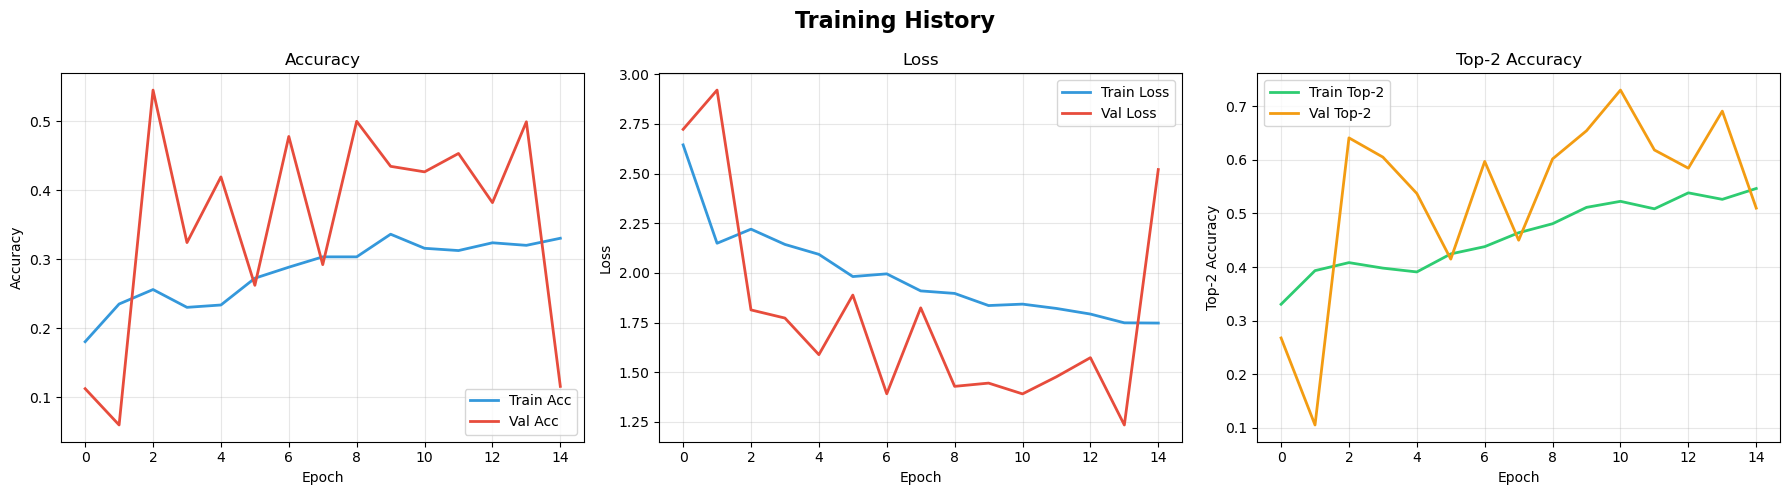

In [12]:

def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Training History', fontsize=16, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Acc',  color='#3498db', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Acc',    color='#e74c3c', linewidth=2)
    axes[0].set_title('Accuracy'); axes[0].legend()
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='#3498db', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c', linewidth=2)
    axes[1].set_title('Loss'); axes[1].legend()
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)

    # Top-2 Accuracy
    if 'top2_accuracy' in history.history:
        axes[2].plot(history.history['top2_accuracy'],     label='Train Top-2', color='#2ecc71', linewidth=2)
        axes[2].plot(history.history['val_top2_accuracy'], label='Val Top-2',   color='#f39c12', linewidth=2)
        axes[2].set_title('Top-2 Accuracy'); axes[2].legend()
        axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Top-2 Accuracy')
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_training_history(history)

## Evaluate on Test Set

In [13]:
# ── Test evaluation ───────────────────────────────────────────────────
print('Evaluating on test set...')
test_results = model.evaluate(test_ds, verbose=1)
print(f'\n✅ Test Loss     : {test_results[0]:.4f}')
print(f'✅ Test Accuracy : {test_results[1]:.4f} ({test_results[1]*100:.2f}%)')

# ── Collect predictions ───────────────────────────────────────────────
y_true, y_pred, y_pred_proba = [], [], []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(probs, axis=1))
    y_pred_proba.extend(probs)

y_true       = np.array(y_true)
y_pred       = np.array(y_pred)
y_pred_proba = np.array(y_pred_proba)

# ── Classification report ─────────────────────────────────────────────
print('\n📋 Classification Report:')
print('='*70)
report = classification_report(
    y_true, y_pred,
    target_names=[f'{c} ({CLASS_FULL_NAMES[c]})' for c in CLASS_NAMES]
)
print(report)

Evaluating on test set...
47/47 ━━━━━━━━━━━━━━━━━━━━ 34s 714ms/step - accuracy: 0.5023 - loss: 1.2508 - top2_accuracy: 0.6786

✅ Test Loss     : 1.2508
✅ Test Accuracy : 0.5023 (50.23%)

📋 Classification Report:
                            precision    recall  f1-score   support

            MEL (Melanoma)       0.28      0.40      0.32       167
     NV (Melanocytic Nevi)       0.88      0.60      0.72      1006
BCC (Basal Cell Carcinoma)       0.34      0.45      0.39        77
 AKIEC (Actinic Keratosis)       0.00      0.00      0.00        49
    BKL (Benign Keratosis)       0.35      0.19      0.25       165
       DF (Dermatofibroma)       0.01      0.06      0.01        17
   VASC (Vascular Lesions)       0.06      0.68      0.10        22

                  accuracy                           0.50      1503
                 macro avg       0.27      0.34      0.26      1503
              weighted avg       0.68      0.50      0.56      1503



##  Confusion Matrix

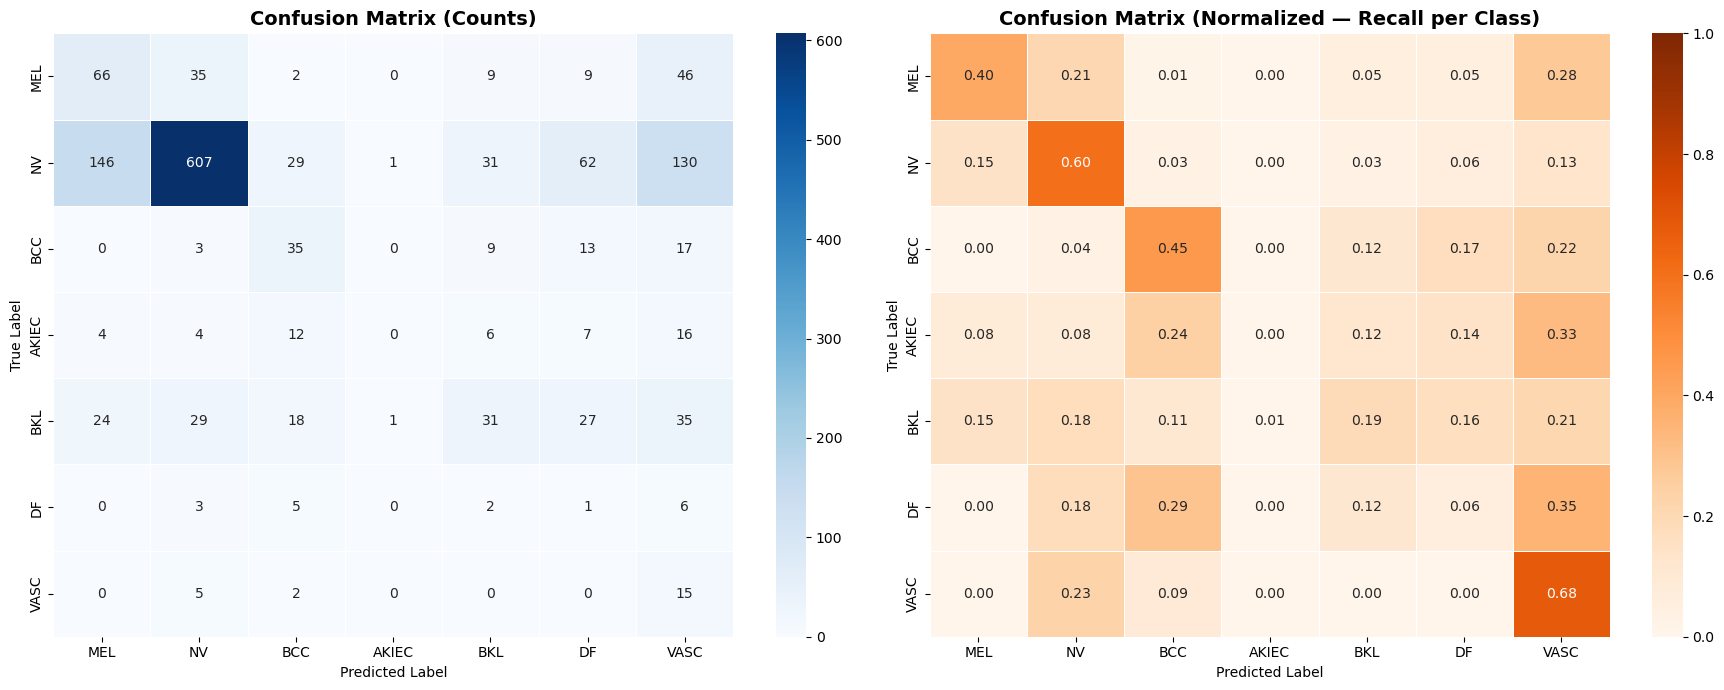

In [14]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Normalized (recall per class)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Oranges',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[1], linewidths=0.5, vmin=0, vmax=1
)
axes[1].set_title('Confusion Matrix (Normalized — Recall per Class)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

##  Save the Model (Keras + H5)

In [15]:
# ── Save as .keras (recommended) ─────────────────────────────────────
model.save(MODEL_SAVE_PATH)
print(f'✅ Model saved as .keras : {MODEL_SAVE_PATH}')

# ── Also save as .h5 (for older TF / Flask compatibility) ─────────────
h5_path = MODEL_SAVE_PATH.replace('.keras', '.h5')
model.save(h5_path)
print(f'✅ Model saved as .h5    : {h5_path}')

# ── Save class names (needed by Flask) ────────────────────────────────
import json
class_info = {
    'class_names'     : CLASS_NAMES,
    'class_full_names': CLASS_FULL_NAMES,
    'img_size'        : IMG_SIZE,
    'num_classes'     : NUM_CLASSES
}
json_path = MODEL_SAVE_PATH.replace('.keras', '_config.json')
with open(json_path, 'w') as f:
    json.dump(class_info, f, indent=2)
print(f'✅ Class config saved    : {json_path}')

# ── Verify we can reload it ───────────────────────────────────────────
loaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print(f'✅ Model reload verified  — input shape: {loaded_model.input_shape}')

✅ Model saved as .keras : C:\Users\VAIBHAV PRABHU\skin_cancer\skin_cancer_model.keras
✅ Model saved as .h5    : C:\Users\VAIBHAV PRABHU\skin_cancer\skin_cancer_model.h5
✅ Class config saved    : C:\Users\VAIBHAV PRABHU\skin_cancer\skin_cancer_model_config.json
✅ Model reload verified  — input shape: (None, 128, 128, 3)


##  Predict a Single Image

True label: NV (Melanocytic Nevi)


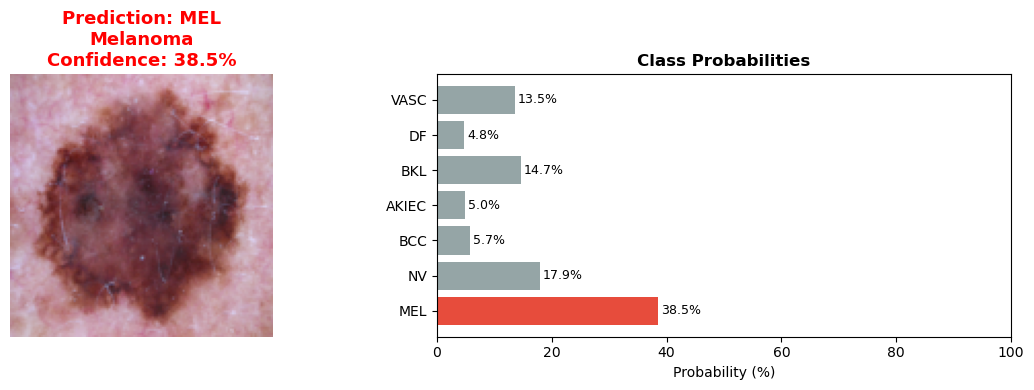


🔬 Prediction Result:
   Class      : MEL (Melanoma)
   Confidence : 38.46%
   All probs  :
     MEL    : ███████████                    38.46%
     NV     : █████                          17.88%
     BCC    : █                              5.70%
     AKIEC  : █                              4.95%
     BKL    : ████                           14.68%
     DF     : █                              4.77%
     VASC   : ████                           13.55%


('MEL',
 38.45909833908081,
 {'MEL': 0.38459098,
  'NV': 0.17880166,
  'BCC': 0.057023328,
  'AKIEC': 0.049535915,
  'BKL': 0.14684252,
  'DF': 0.0477063,
  'VASC': 0.13549928})

In [27]:
def predict_single_image(image_path, model, show_plot=True):
    """
    Predict skin lesion class from a single image file.
    Returns: (predicted_class, confidence, all_probabilities)
    """
    # Load & preprocess
    img = Image.open("C:\\Users\\VAIBHAV PRABHU\\Downloads\\archive\\images\\ISIC_0034294.jpg").convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dim → (1, H, W, 3)

    # Predict
    probs     = model.predict(img_array, verbose=0)[0]
    pred_idx  = np.argmax(probs)
    pred_cls  = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100

    if show_plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # Show image
        ax1.imshow(img)
        ax1.axis('off')
        ax1.set_title(
            f'Prediction: {pred_cls}\n{CLASS_FULL_NAMES[pred_cls]}\nConfidence: {confidence:.1f}%',
            fontsize=13, fontweight='bold',
            color='red' if pred_cls == 'MEL' else 'green'
        )

        # Probability bar chart
        colors_bar = ['#e74c3c' if c == pred_cls else '#95a5a6' for c in CLASS_NAMES]
        bars = ax2.barh(CLASS_NAMES, probs * 100, color=colors_bar)
        ax2.set_xlabel('Probability (%)')
        ax2.set_title('Class Probabilities', fontweight='bold')
        ax2.set_xlim(0, 100)
        for bar, prob in zip(bars, probs):
            ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{prob*100:.1f}%', va='center', fontsize=9)

        plt.tight_layout()
        plt.show()

    print(f'\n🔬 Prediction Result:')
    print(f'   Class      : {pred_cls} ({CLASS_FULL_NAMES[pred_cls]})')
    print(f'   Confidence : {confidence:.2f}%')
    print(f'   All probs  :')
    for cls, prob in zip(CLASS_NAMES, probs):
        bar = '█' * int(prob * 30)
        print(f'     {cls:6s} : {bar:<30s} {prob*100:.2f}%')

    return pred_cls, confidence, dict(zip(CLASS_NAMES, probs))


# ── Test on a sample image from the test set ──────────────────────────
sample_row = test_df.sample(1, random_state=42).iloc[0]
print(f'True label: {sample_row["class_name"]} ({CLASS_FULL_NAMES[sample_row["class_name"]]})')
predict_single_image(sample_row['filepath'], model)

In [6]:
import pandas as pd

df = pd.read_csv("C:\\Users\\VAIBHAV PRABHU\\Downloads\\archive\\GroundTruth.csv")
# df.head()
df[df["image"] == "ISIC_0028751"]

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
4445,ISIC_0028751,0.0,1.0,0.0,0.0,0.0,0.0,0.0
